In [1]:
%load_ext autoreload
%autoreload 2
# !hostname
# !pwd
import os, sys
# print(sys.executable)
# os.environ['CUDA_VISIBLE_DEVICES'] = "7"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = "false"
# sys.path.append(os.path.abspath(".."))

In [2]:
import os, sys, glob, pickle, copy, time
from functools import partial

import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = (15, 5)
import seaborn as sns
sns.set_theme()

from tqdm.auto import tqdm
from einops import rearrange, reduce, repeat
# from einop import einop

import jax
import jax.numpy as jnp
from jax.random import split

import flax
import flax.linen as nn
from flax.training.train_state import TrainState

import optax

import experiment_utils
from main import *
import plotstyle
plotstyle.set_plot_style()

In [3]:
# ! wget -P ./data https://pub.sakana.ai/asal/data/sweep_gol.npz

In [4]:
import clip_pred
argd = clip_pred.Args()

# args = clip_pred.Args(data=clip_pred.DataArgs(n_worlds=5))
argd.n_iters = 300000
argd.log_every = 10000

argd.opt.weight_decay = 1e-5

args_all = []
seeds_all = range(3)
n_worlds_all = [10, 1000, 10000, 100000, 262144]
for seed in seeds_all:
    for n_worlds in n_worlds_all:
            args = copy.deepcopy(argd)
            args.seed = seed
            args.data.n_worlds = n_worlds

            args.save_dir = f"/home/akarsh_sakana_ai/alife-repr-data/run_clip_pred_1/seed={seed}_n_worlds={n_worlds}"
            args_all.append(args)
            # print(args)
experiment_utils.create_commands(args_all, prefix="python clip_pred.py", out_file="science_scripts/clip_pred.sh");

In [5]:
args = args_all[0]

In [5]:
import copy
args = copy.deepcopy(args_all[0])
# args.model.n_layers = 4
# args.model.d_hidden = 512
args.n_iters = 10000
print(args)

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_clip_pred_0/seed=0_n_worlds=10', cache_dataset_dir='./data/', n_iters=10000, log_every=10000, model=ModelArgs(d_hidden=1024, n_layers=16), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=10))


In [6]:
main = clip_pred.Main(args)
main.init()

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_clip_pred_0/seed=0_n_worlds=10', cache_dataset_dir='./data/', n_iters=10000, log_every=10000, model=ModelArgs(d_hidden=1024, n_layers=16), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=10))
Loaded cached dataset from ./data/
identity
Number of parameters: 34,164,224


In [7]:
main.step()

identity
identity


In [8]:
main.metrics.keys()

dict_keys(['clip_vec', 'gol_params', 'grads', 'loss', 'pred'])

In [9]:
grads = main.metrics['grads']

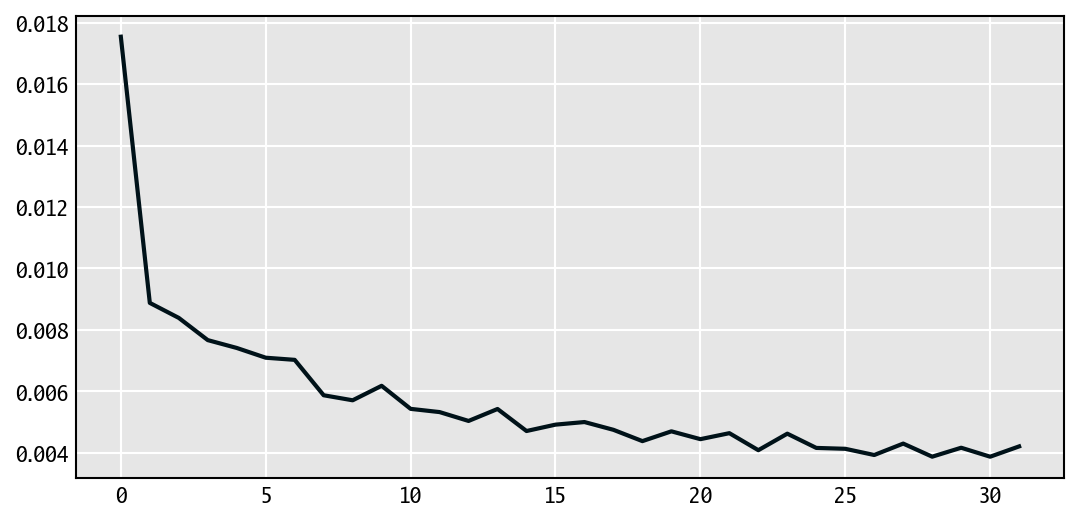

In [10]:
def flatten(a):
    return jnp.concatenate([f.flatten() for f in jax.tree.leaves(a)])
def flatten_abs_mean(a):
    return jnp.abs(flatten(a)).mean()
plt.plot([flatten_abs_mean(grads['params'][f"Dense_{i}"]).item() for i in range(16*2)] )

In [36]:
main.run()

  0%|          | 0/10000 [00:00<?, ?it/s]

 50%|█████     | 5024/10000 [00:27<00:27, 180.78it/s, loss=0.959, ppl=2.61]


KeyboardInterrupt: 

In [25]:
rng = jax.random.PRNGKey(0)
batch = main.generate_batch(rng)

In [19]:
args = args_all[4]
print(args)

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_clip_pred_1/seed=0_n_worlds=262144', cache_dataset_dir='./data/', n_iters=300000, log_every=10000, model=ModelArgs(d_hidden=1024, n_layers=16), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=262144))


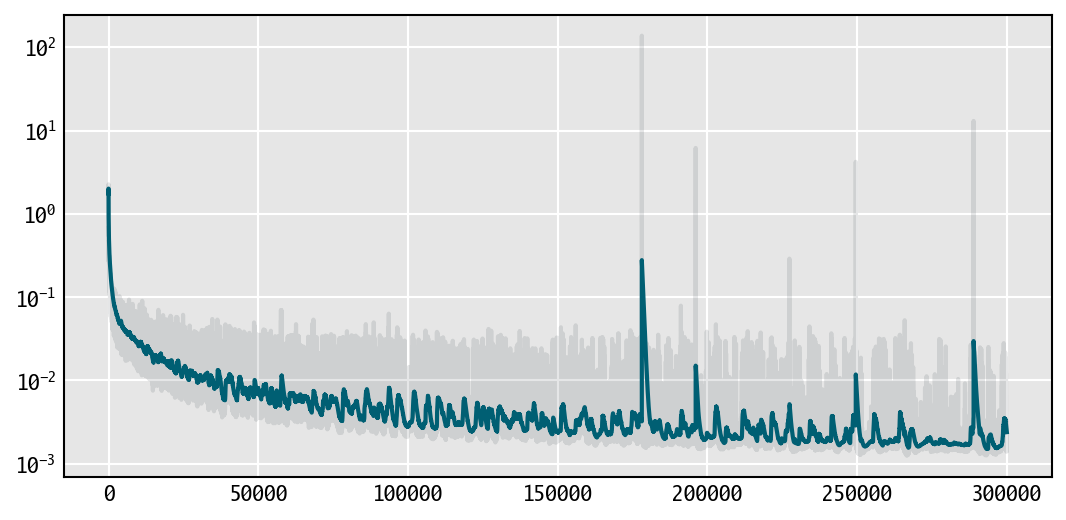

In [20]:
loss_history = util.load_pkl(args.save_dir, "loss_history")
plt.plot(loss_history, alpha=0.1)
loss_history = pd.DataFrame(loss_history).ewm(span=1000).mean()
plt.plot(loss_history)
# plt.axhline(y=9.0274756e-05, color='red')
# plt.axhline(y=4e-05, color='red')
plt.yscale('log')
# plt.ylim(8e-5, 1e-4)
# plt.ylim(1e-5, 1e-4)

In [21]:
main = clip_pred.Main(args)

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_clip_pred_1/seed=0_n_worlds=262144', cache_dataset_dir='./data/', n_iters=300000, log_every=10000, model=ModelArgs(d_hidden=1024, n_layers=16), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=262144))


In [22]:
main.init()

Loaded cached dataset from ./data/
identity
Number of parameters: 34,164,224


In [23]:
# rng = jax.random.PRNGKey(0)
# batch = main.generate_batch(rng, train=True)
# print(batch['gol_params'])
# print(jnp.unique(batch['gol_params']))
# batch = main.generate_batch(rng, train=False)
# print(batch['gol_params'])
# print(jnp.unique(batch['gol_params']))

In [24]:
clip_dataset = main.clip_dataset[:args.data.n_worlds]
mean = clip_dataset.mean(axis=0)

In [25]:
((clip_dataset-mean)**2).mean()

Array(0.9999975, dtype=float32)

In [26]:
params = util.load_pkl(args.save_dir, "params")
# params = main.train_state.params
# params = jax.tree.map(lambda x: jnp.zeros_like(x), params)

In [27]:
rng = jax.random.PRNGKey(0)
batch = main.generate_batch(rng, train=False)
loss, metrics = main.loss_fn(params, batch)

identity


In [28]:
y, pred = metrics['clip_vec'], metrics['pred']
# pred = jnp.zeros_like(pred)
print(y.shape, pred.shape)

(256, 512) (256, 512)


In [29]:
import sklearn
sklearn.metrics.r2_score(y, pred)

0.9887045621871948

In [30]:
(1 - ((y-pred)**2).sum(axis=0) / ((y.mean(axis=0)-y)**2).sum(axis=0)).mean()

Array(0.98870456, dtype=float32)

In [34]:
import sklearn

df = []
for args in tqdm(args_all):
    main = clip_pred.Main(args)
    main.init()
    params = util.load_pkl(args.save_dir, "params")
    rng = jax.random.PRNGKey(0)

    batch = main.generate_batch(rng, train=True)
    loss, metrics = main.loss_fn(params, batch)
    y, pred = metrics['clip_vec'], metrics['pred']
    r2_train = sklearn.metrics.r2_score(y, pred)

    batch = main.generate_batch(rng, train=False)
    loss, metrics = main.loss_fn(params, batch)
    y, pred = metrics['clip_vec'], metrics['pred']
    r2_test = sklearn.metrics.r2_score(y, pred)
    
    dfi = dict(seed=args.seed, n_worlds=args.data.n_worlds, r2_train=r2_train, r2_test=r2_test)
    df.append(dfi)

df = pd.DataFrame(df)

  0%|          | 0/15 [00:00<?, ?it/s]

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_clip_pred_1/seed=0_n_worlds=10', cache_dataset_dir='./data/', n_iters=300000, log_every=10000, model=ModelArgs(d_hidden=1024, n_layers=16), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=10))
Loaded cached dataset from ./data/
identity
Number of parameters: 34,164,224
identity
identity


  7%|▋         | 1/15 [00:05<01:14,  5.35s/it]

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_clip_pred_1/seed=0_n_worlds=1000', cache_dataset_dir='./data/', n_iters=300000, log_every=10000, model=ModelArgs(d_hidden=1024, n_layers=16), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=1000))
Loaded cached dataset from ./data/
identity
Number of parameters: 34,164,224
identity
identity


 13%|█▎        | 2/15 [00:11<01:14,  5.72s/it]

...

 87%|████████▋ | 13/15 [01:07<00:10,  5.04s/it]

Args(seed=2, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_clip_pred_1/seed=2_n_worlds=100000', cache_dataset_dir='./data/', n_iters=300000, log_every=10000, model=ModelArgs(d_hidden=1024, n_layers=16), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=100000))
Loaded cached dataset from ./data/
identity
Number of parameters: 34,164,224
identity
identity


 93%|█████████▎| 14/15 [01:13<00:05,  5.33s/it]

Args(seed=2, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_clip_pred_1/seed=2_n_worlds=262144', cache_dataset_dir='./data/', n_iters=300000, log_every=10000, model=ModelArgs(d_hidden=1024, n_layers=16), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=262144))
Loaded cached dataset from ./data/
identity
Number of parameters: 34,164,224
identity
identity


100%|██████████| 15/15 [01:21<00:00,  5.43s/it]


In [35]:
df

,seed,n_worlds,r2_train,r2_test
0,0,10,1.000000,-503.295441
1,0,1000,0.999526,0.601025
2,0,10000,0.996143,0.861068
3,0,100000,0.996103,0.913165
4,0,262144,0.998423,0.988705
5,1,10,0.998905,-11.156016
6,1,1000,0.999836,0.697243
7,1,10000,0.996722,0.850938
8,1,100000,0.994809,0.984757
9,1,262144,0.997919,0.996554


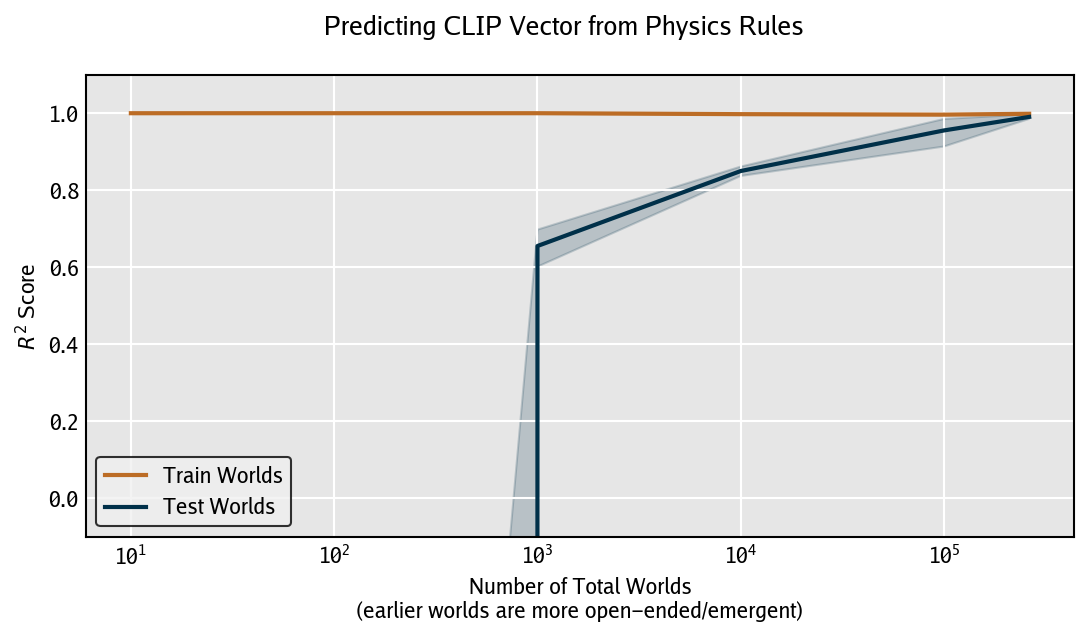

In [49]:
sns.lineplot(data=df, x='n_worlds', y='r2_train', label='Train Worlds', color='#bc6c25')
sns.lineplot(data=df, x='n_worlds', y='r2_test', label='Test Worlds', color='#003049')
plt.xlabel("Number of Total Worlds\n(earlier worlds are more open-ended/emergent)")
plt.ylabel("$R^2$ Score")
plt.suptitle("Predicting CLIP Vector from Physics Rules")
plt.ylim(-.1, 1.1)
plt.xscale('log')
plt.legend()
plt.show()

In [44]:
gol_data = np.load("./data/sweep_gol.npz", allow_pickle=True)
params_all = gol_data['params']
oe_score_all = gol_data['oe_score']
print(params_all.shape) # shape: (number of simulations, )


(262144,)


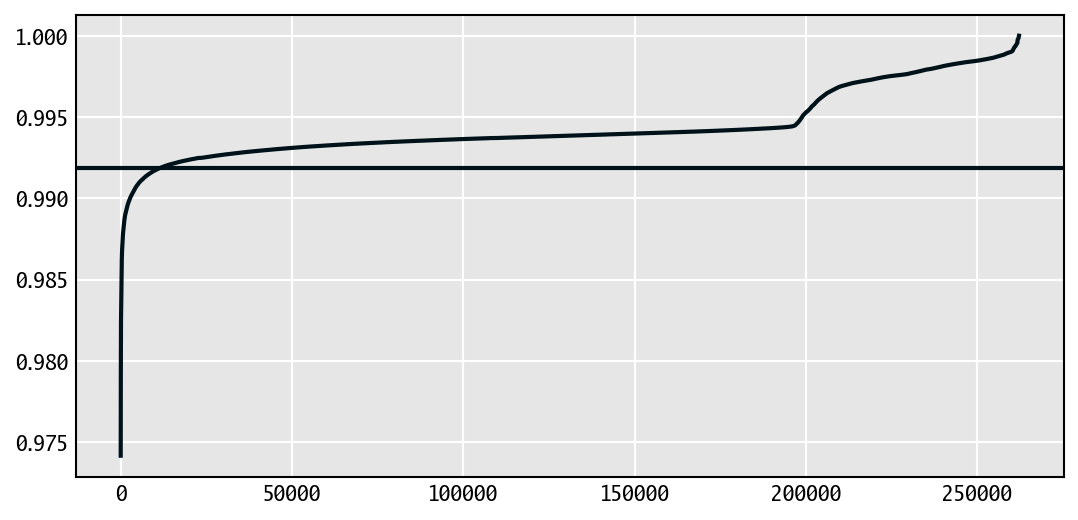

In [51]:
plt.plot(oe_score_all)
plt.axhline(0.99189597)

In [52]:
oe_score_all[params_all==6152]

array([0.99189597])

In [55]:
(oe_score_all<0.99189597).sum()

np.int64(11669)

In [13]:
from foundation_models import create_foundation_model

substrate = GameOfLife(grid_size=64)
fm = create_foundation_model('clip')
rollout_fn = partial(rollout_simulation, s0=None, substrate=substrate, fm=None, rollout_steps=128, time_sampling='video', img_size=224, return_state=True)



In [39]:
rng = jax.random.PRNGKey(0)
params = 6152

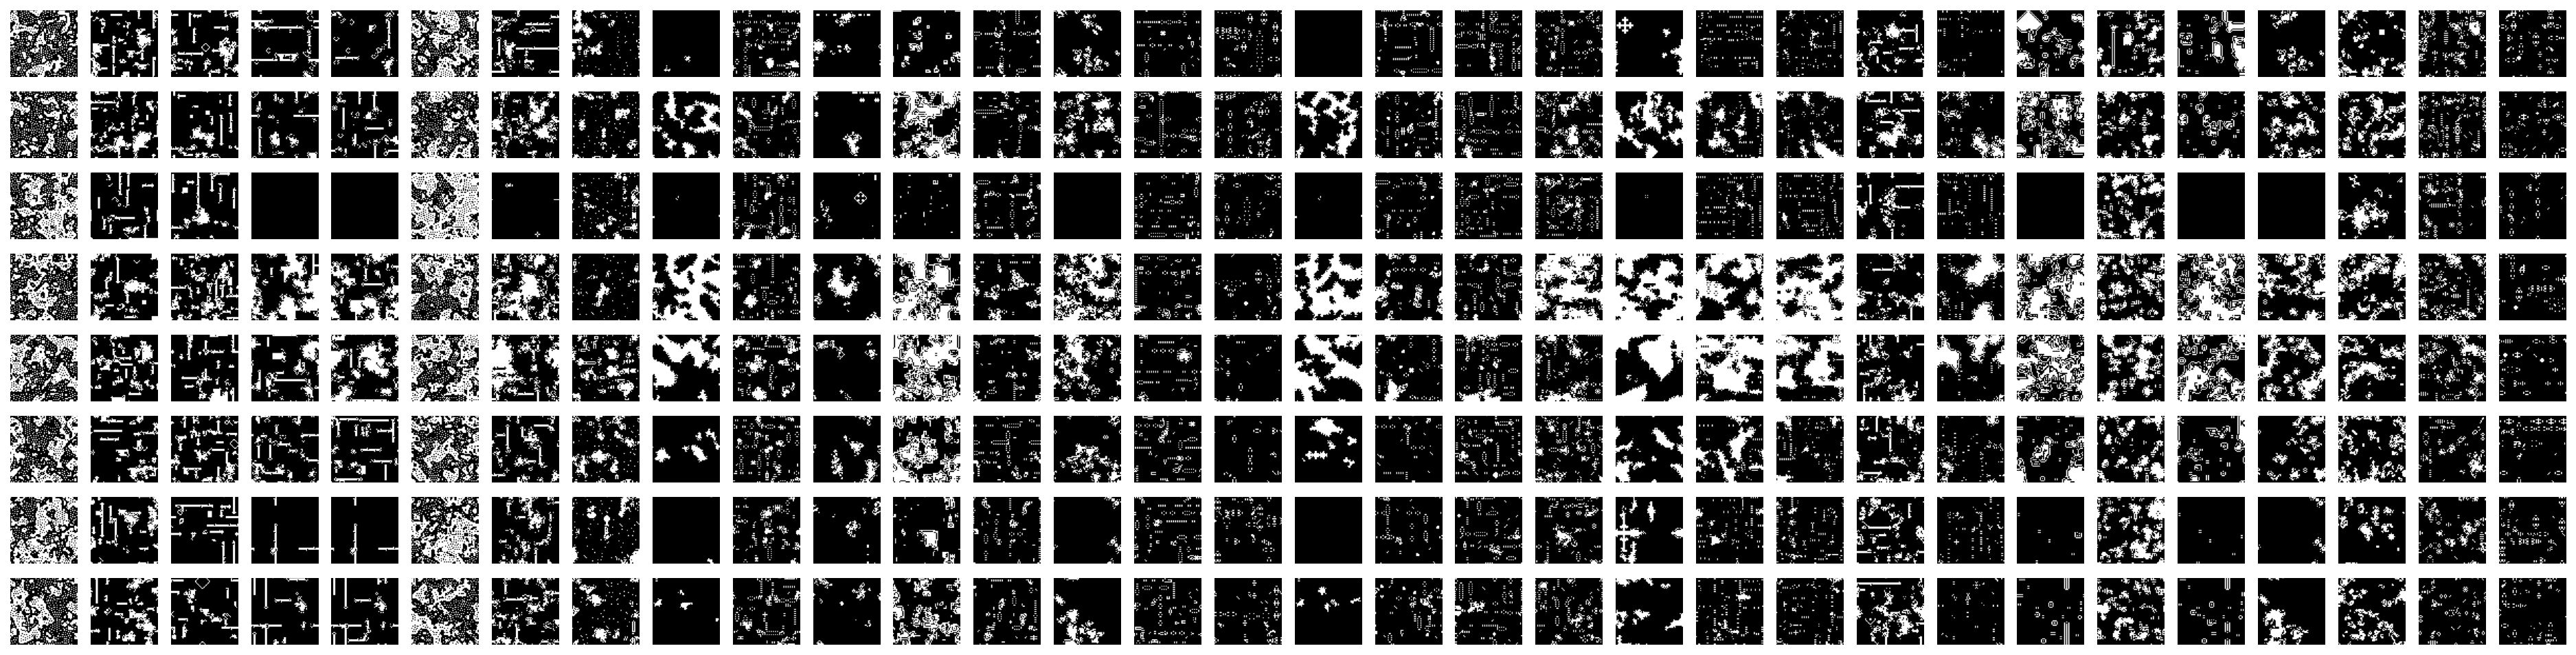

In [40]:
def get_img(rng, params):
    rgb = rollout_fn(rng, params)['rgb']
    t0 = jax.random.randint(rng, shape=(), minval=len(rgb)//2, maxval=len(rgb))
    t0 = t0 - t0%2 # make sure t0 is even
    rgb = rgb[t0]
    return rgb
def get_imgs(rng, params, batch_size=128):
    imgs = jax.vmap(get_img, in_axes=(0, None))(split(rng, batch_size), params)
    return imgs
plt.figure(figsize=(32, 8))
for i, params in enumerate(params_all[:32]):
    imgs = get_imgs(rng, params)
    for j in range(8):
        plt.subplot(8, 32, j*32+i+1)
        plt.imshow(imgs[j])
        plt.axis('off')
plt.show()

In [41]:
def get_avg_clip_vec(rng, params, batch_size=128):
    imgs = jax.vmap(get_img, in_axes=(0, None))(split(rng, batch_size), params)
    z = jax.vmap(fm.embed_img)(imgs)
    z_avg = z.mean(axis=0)
    return dict(imgs=imgs, z=z, z_avg=z_avg)

get_avg_clip_vec = jax.jit(get_avg_clip_vec)

rng = jax.random.PRNGKey(0)

params2clip = {}
for params in tqdm(params_all):
    a = get_avg_clip_vec(rng, params)
    params2clip[params] = a['z_avg']


  4%|▍         | 10674/262144 [03:31<1:22:54, 50.55it/s]


KeyboardInterrupt: 

In [42]:
from substrates.gol import int2binary

In [43]:
int2binary(6152)

Array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0], dtype=int32)

In [4]:
clip_dataset = util.load_pkl("./data/", "clip_dataset")

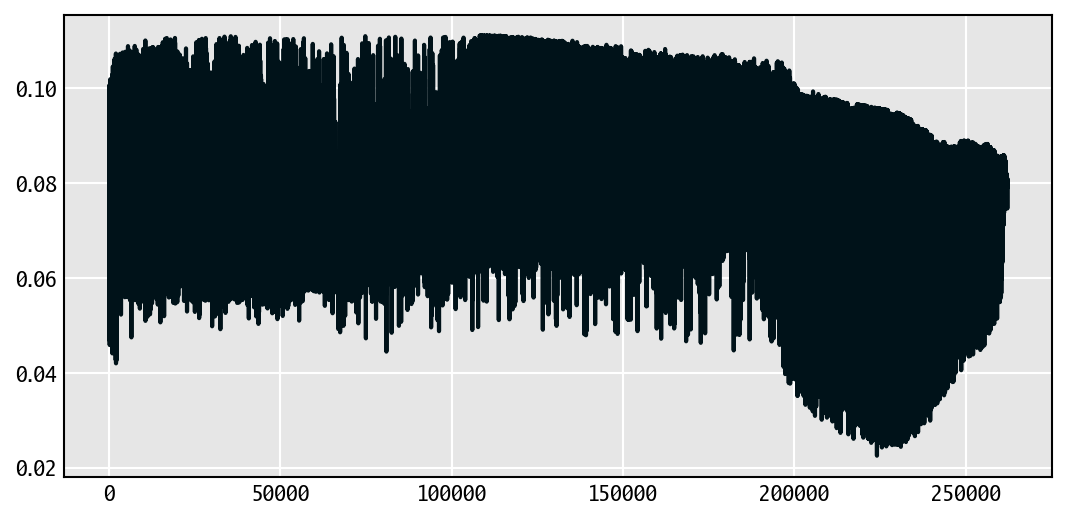

In [9]:
plt.plot(clip_dataset[:, 7])